# Lesson 3: Data Visualization with Matplotlib & Seaborn

Prepared by Festus Ogungbemiro

## Overview
In this lesson, we will explore two of the most popular data visualization libraries in Python: **Matplotlib** and **Seaborn**. Visualisation is an important skill in nanoinformatics because it helps you explore data, identify patterns, and communicate results effectively. By the end of this lesson, you will be able to create a wide range of plots, from simple line charts to complex statistical visualisations, and customise them to publication quality.

We will use a simulated dataset inspired by the Materials Project, containing properties like band gap, formation energy, density, and crystal system. This will give you hands‑on experience with the kind of data you will encounter in later lessons.

## Learning Objectives
After completing this lesson, you will be able to:
- Create basic plots (line, scatter, bar, histogram) using Matplotlib.
- Customise plots with titles, labels, legends, colours, and styles.
- Use Seaborn to create attractive statistical plots (box plots, violin plots, heatmaps, pair plots).
- Combine multiple plots in a single figure (subplots).
- Save figures in high resolution for publication.
- Apply these skills to visualise materials science data (e.g., band gap distributions, property correlations).

## Prerequisites
- Completion of Lessons 1 and 2 (or equivalent Python and Pandas knowledge).
- Python 3.8+ with Jupyter Notebook.
- Libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`.

---
## 1. Setting Up the Environment

First, we need to import the required libraries. We'll also set some default styling for publication‑quality figures. These settings will be applied to all subsequent plots.

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")  # Set a default colour palette for Seaborn

# Configure matplotlib for high-quality output (suitable for publications)
plt.rcParams['figure.dpi'] = 150          # display resolution
plt.rcParams['savefig.dpi'] = 300         # save resolution (high)
plt.rcParams['font.size'] = 12             # base font size
plt.rcParams['axes.labelsize'] = 14        # axis label font size
plt.rcParams['axes.titlesize'] = 16        # title font size
plt.rcParams['legend.fontsize'] = 12       # legend font size
plt.rcParams['xtick.labelsize'] = 12       # x‑tick label size
plt.rcParams['ytick.labelsize'] = 12       # y‑tick label size

print("Libraries imported and styling configured.")

Libraries imported and styling configured.


### 1.1 Creating a Sample Dataset
To make the examples concrete, we'll create a simulated dataset that resembles what we might get from the Materials Project. This dataset will contain information about several materials, including their band gaps, formation energies, densities, volumes, and crystal systems.

We'll use NumPy's random functions to generate synthetic data and store it in a Pandas DataFrame.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 200  # number of materials

# Generate synthetic data
data = {
    "material_id": [f"mp-{i}" for i in range(1000, 1000 + n_samples)],
    "formula": np.random.choice(["Ag", "Cu", "Zn", "Ti", "Au", "Mg", "Fe"], n_samples),
    "band_gap": np.random.uniform(0, 5, n_samples),
    "formation_energy_per_atom": np.random.uniform(-2, 1, n_samples),
    "density": np.random.uniform(2, 12, n_samples),
    "volume": np.random.uniform(50, 200, n_samples),
    "crystal_system": np.random.choice(["cubic", "hexagonal", "tetragonal", "orthorhombic"], n_samples)
}

df = pd.DataFrame(data)
print("Sample data (first 5 rows):")
df.head()

Sample data (first 5 rows):


,material_id,formula,band_gap,formation_energy_per_atom,density,volume,crystal_system
0,mp-1000,Fe,1.478168,-1.757381,7.515879,169.143417,orthorhombic
1,mp-1001,Ti,0.527471,-0.715057,3.648343,66.004888,hexagonal
2,mp-1002,Au,2.282673,0.065500,6.112551,177.609119,cubic
3,mp-1003,Fe,1.092202,-1.825419,9.776023,161.896179,hexagonal
4,mp-1004,Zn,2.082550,0.745641,6.803701,111.277744,cubic


Let's also check basic information about our dataset to ensure everything looks correct.

In [3]:
print("DataFrame info:")
df.info()
print("\nSummary statistics:")
df.describe()

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   material_id                200 non-null    object 
 1   formula                    200 non-null    object 
 2   band_gap                   200 non-null    float64
 3   formation_energy_per_atom  200 non-null    float64
 4   density                    200 non-null    float64
 5   volume                     200 non-null    float64
 6   crystal_system             200 non-null    object 
dtypes: float64(4), object(3)
memory usage: 11.1+ KB

Summary statistics:


,band_gap,formation_energy_per_atom,density,volume
count,200.000000,200.000000,200.000000,200.000000
mean,2.463540,-0.491210,6.983810,129.141940
std,1.419390,0.867159,2.813035,40.855884
min,0.002602,-1.954086,2.025950,51.830461
25%,1.298368,-1.239472,4.643650,96.719892
50%,2.284499,-0.511102,7.305529,130.973127
75%,3.564259,0.211156,9.288596,165.024332
max,4.988702,0.987794,11.972555,199.653892


---
## 2. Basic Plotting with Matplotlib

Matplotlib is the foundational plotting library in Python. It gives you fine‑grained control over every aspect of your figures. We'll start with the most common plot types.

### 2.1 Line Plot
Line plots are useful for showing trends over a continuous variable (e.g., band gap vs. atomic number). Here we'll create a simple line plot using dummy data to illustrate the concept.

**When to use**: Showing a function, time series, or any ordered sequence.

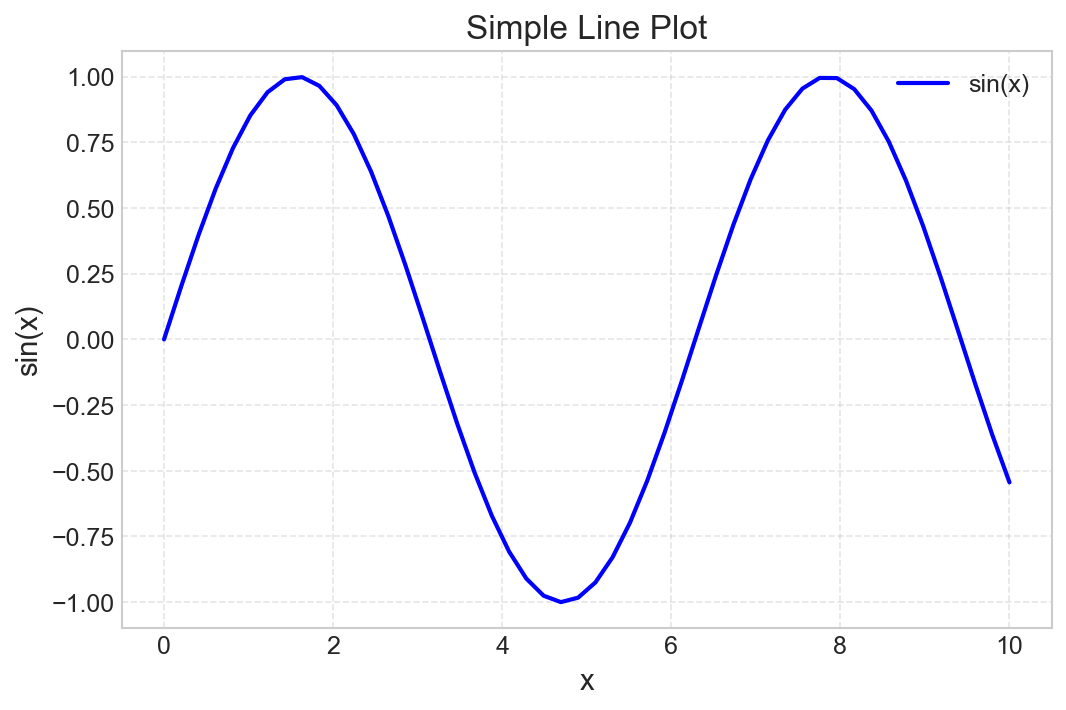

In [4]:
# Create dummy data
x = np.linspace(0, 10, 50)      # 50 points from 0 to 10
y = np.sin(x)                    # sine of x

plt.figure(figsize=(8, 5))       # create a figure of size 8x5 inches
plt.plot(x, y, label='sin(x)', color='blue', linewidth=2)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Simple Line Plot')
plt.legend()                      # display the legend
plt.grid(True, linestyle='--', alpha=0.5)   # add a light dashed grid
plt.show()

**Explanation**:
- `plt.figure(figsize=(8,5))` creates a new figure with specified dimensions.
- `plt.plot()` draws the line; we can customise colour, line width, and label.
- `plt.xlabel()`, `plt.ylabel()`, `plt.title()` add labels and title.
- `plt.legend()` displays the label defined in `plot()`.
- `plt.grid()` adds a grid for better readability.
- `plt.show()` displays the plot.

### 2.2 Scatter Plot
Scatter plots are ideal for showing the relationship between two numerical variables. Let's plot band gap vs. formation energy for our materials.

**When to use**: Exploring correlations, identifying clusters, or visualising distributions of two variables.

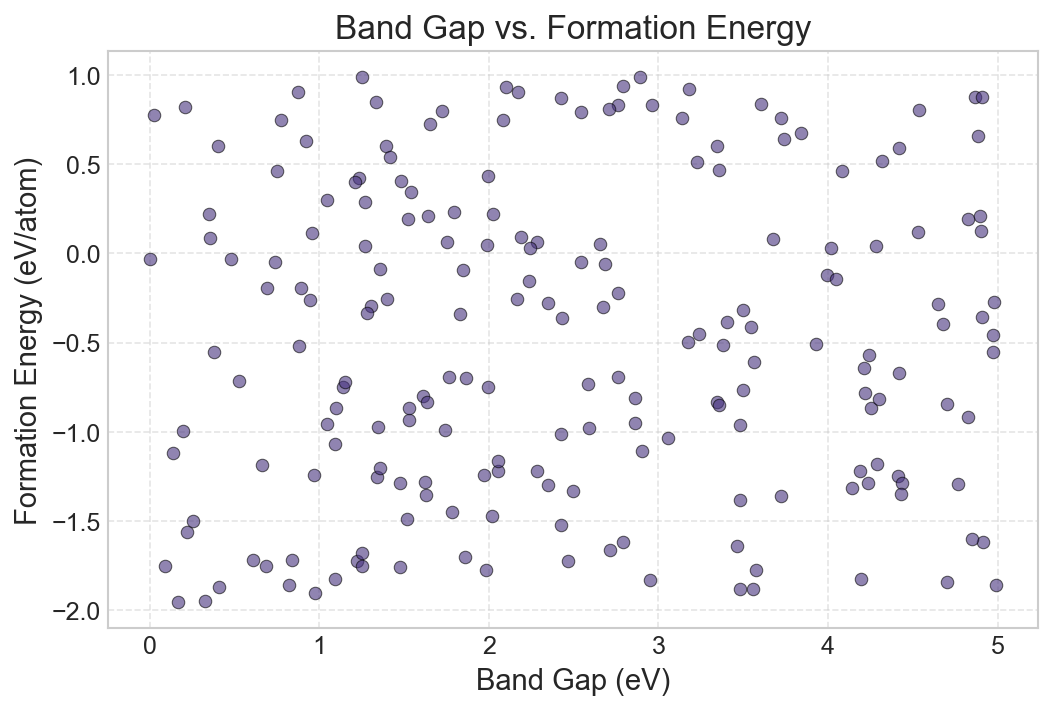

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['band_gap'], df['formation_energy_per_atom'], 
            alpha=0.6, edgecolors='k', linewidth=0.5)
plt.xlabel('Band Gap (eV)')
plt.ylabel('Formation Energy (eV/atom)')
plt.title('Band Gap vs. Formation Energy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Explanation**:
- `plt.scatter(x, y, ...)` creates a scatter plot.
- `alpha=0.6` makes points semi‑transparent, useful when many points overlap.
- `edgecolors='k'` adds a black outline to each point for better definition.

### 2.3 Bar Plot
Bar plots are great for comparing quantities across categories. Let's count how many materials belong to each crystal system and visualise the counts.

**When to use**: Comparing categorical data, showing frequencies, or displaying aggregated values.

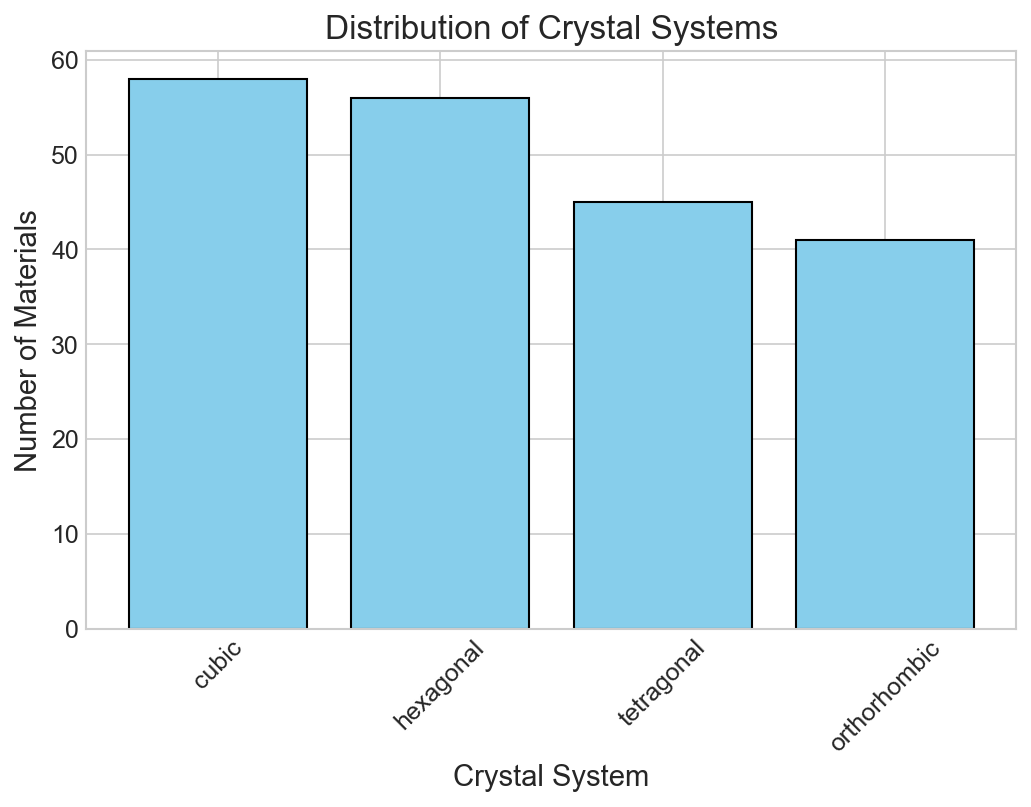

In [6]:
# Count occurrences of each crystal system
counts = df['crystal_system'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Crystal System')
plt.ylabel('Number of Materials')
plt.title('Distribution of Crystal Systems')
plt.xticks(rotation=45)   # rotate x‑axis labels for better readability
plt.show()

**Explanation**:
- `value_counts()` returns a Series with counts for each unique category.
- `plt.bar(categories, heights, ...)` draws a bar plot.
- `plt.xticks(rotation=45)` tilts the labels so they don't overlap.

### 2.4 Histogram
Histograms show the distribution of a single numerical variable. Let's look at the distribution of band gaps.

**When to use**: Understanding the spread, central tendency, and shape of a continuous variable.

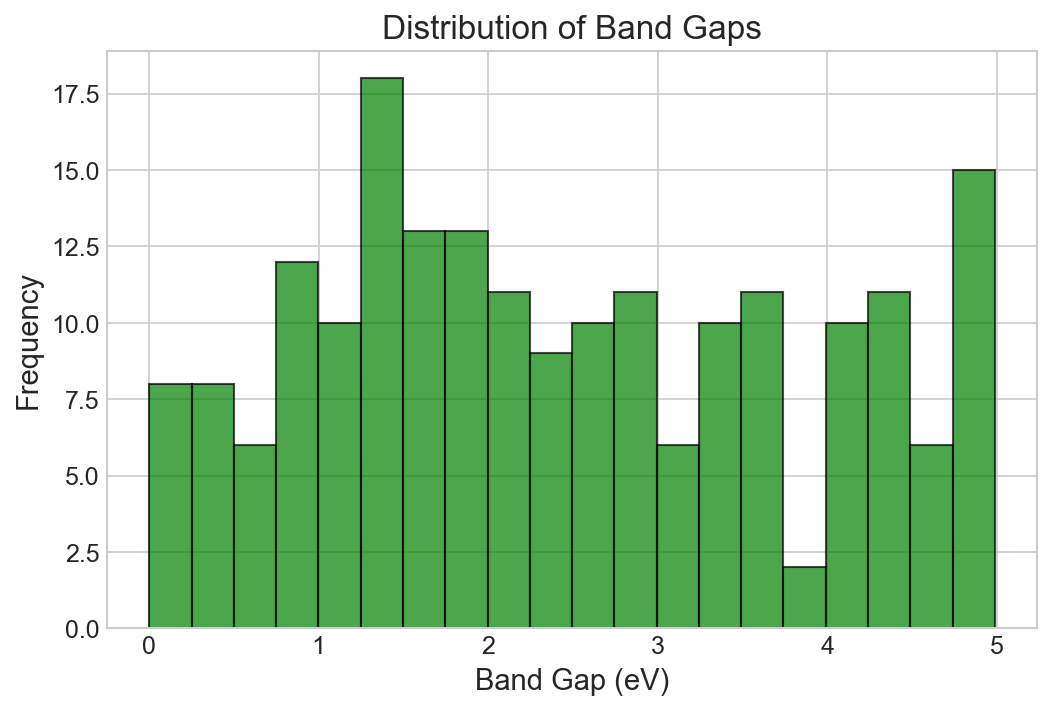

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['band_gap'], bins=20, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Band Gap (eV)')
plt.ylabel('Frequency')
plt.title('Distribution of Band Gaps')
plt.show()

**Explanation**:
- `bins=20` divides the data into 20 equal‑width bins.
- `alpha=0.7` adds some transparency.
- The histogram shows how many materials fall into each band‑gap range.

**Exercise 2.1**: Create a histogram of the formation energy per atom using 30 bins. Add appropriate labels and a title.

In [8]:
# Your code here
# Hint: use df['formation_energy_per_atom'] as the data

---
## 3. Customising Plots

Matplotlib allows extensive customisation. We'll cover some of the most common adjustments, such as colours, markers, line styles, and adding a colour bar to encode a third variable.

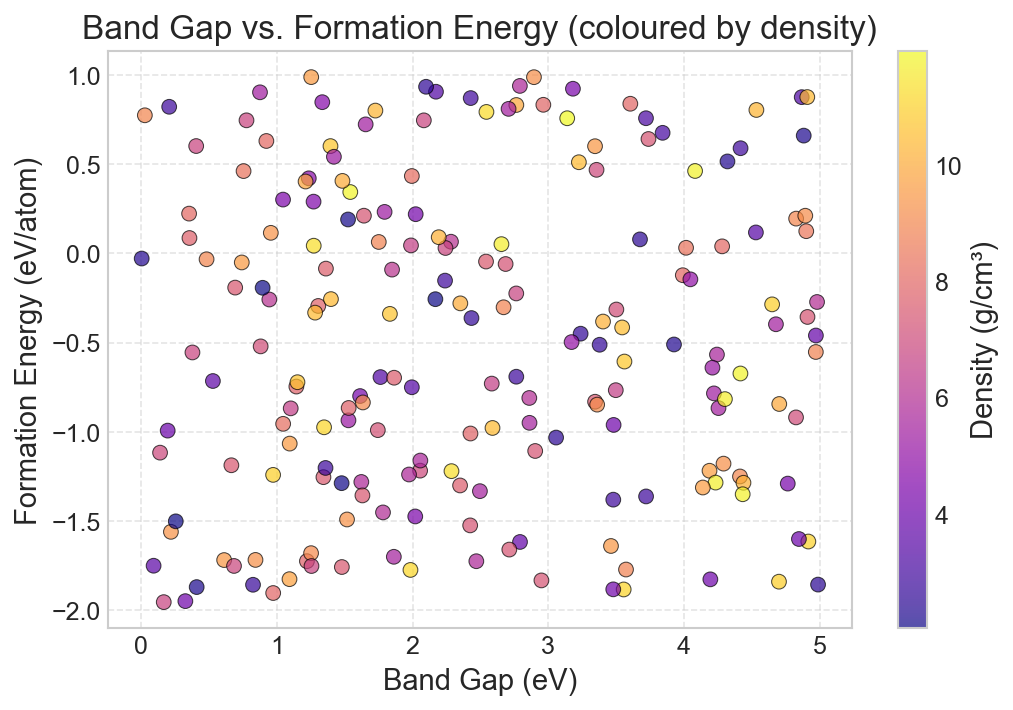

In [9]:
# Create a scatter plot with points coloured by density
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['band_gap'], df['formation_energy_per_atom'],
                      c=df['density'], cmap='plasma', s=50, alpha=0.7,
                      edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(scatter)                     # add colour bar
cbar.set_label('Density (g/cm³)')
plt.xlabel('Band Gap (eV)')
plt.ylabel('Formation Energy (eV/atom)')
plt.title('Band Gap vs. Formation Energy (coloured by density)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Explanation**:
- `c=df['density']` uses the density values to determine point colours.
- `cmap='plasma'` selects a colour map (see Matplotlib documentation for many options).
- `plt.colorbar(scatter)` adds a colour bar that maps colours to values.
- `cbar.set_label()` labels the colour bar.

**Exercise 3.1**: Modify the above plot to colour the points by crystal system instead of density. (Hint: you may need to convert the categorical variable to numerical codes using `pd.Categorical(df['crystal_system']).codes`. Then choose an appropriate discrete colour map like `'tab10'`.)

In [10]:
# Your code here

---
## 4. Subplots
Often you need to place multiple plots side by side for comparison. Matplotlib's `subplots()` function makes this easy.

**When to use**: Showing multiple related visualisations in a single figure.

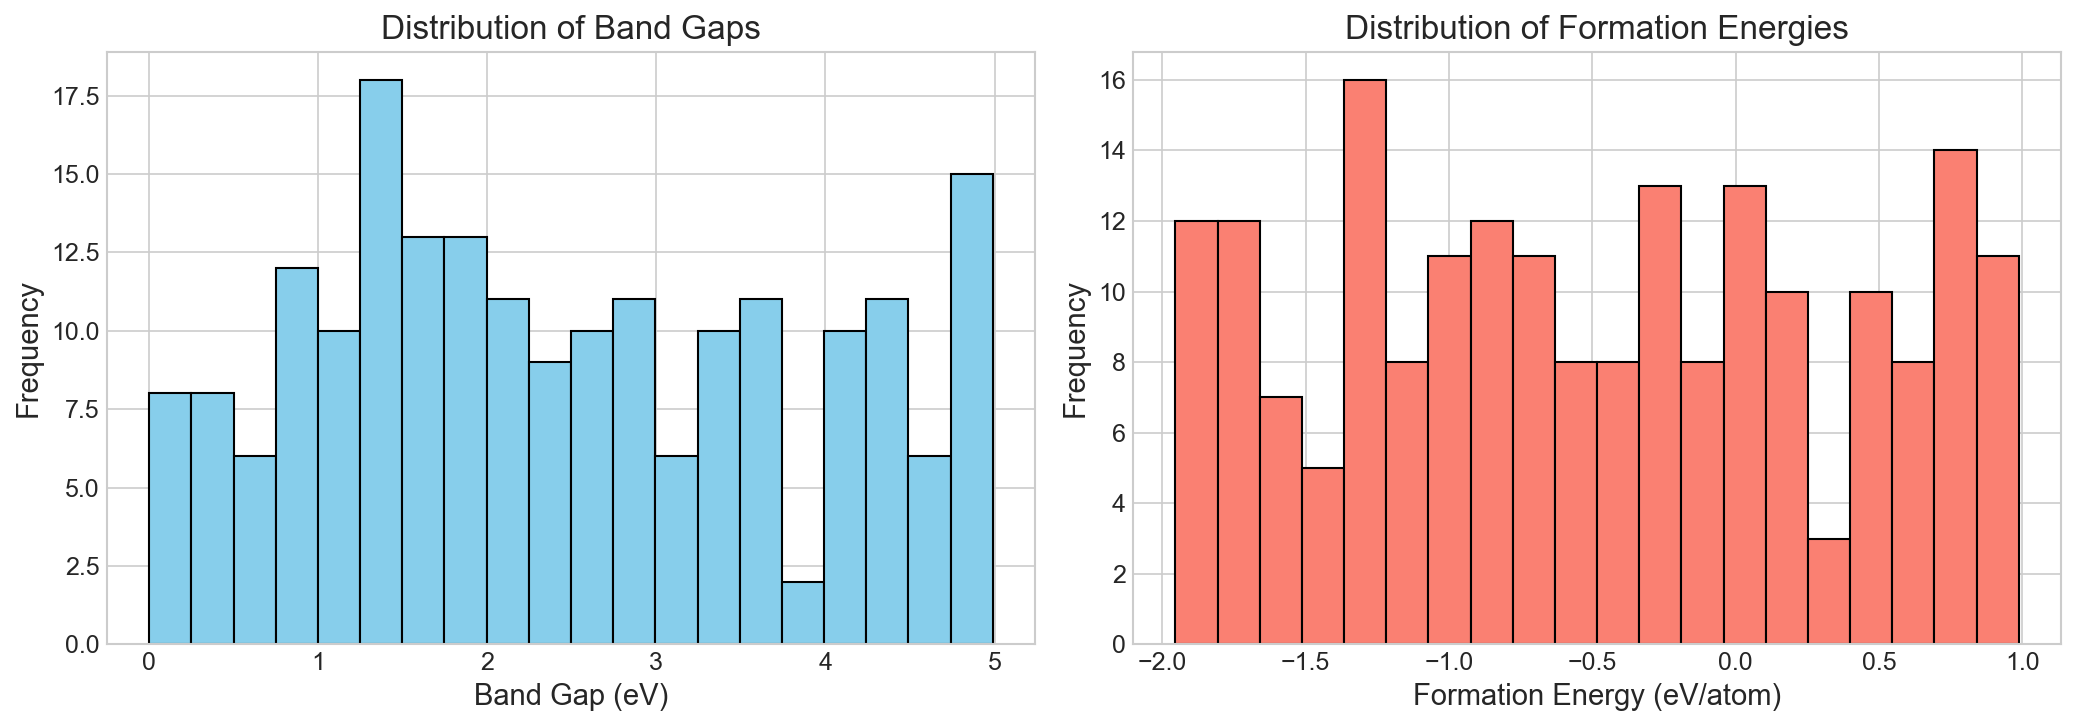

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First subplot: histogram of band gaps
axes[0].hist(df['band_gap'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Band Gap (eV)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Band Gaps')

# Second subplot: histogram of formation energies
axes[1].hist(df['formation_energy_per_atom'], bins=20, color='salmon', edgecolor='black')
axes[1].set_xlabel('Formation Energy (eV/atom)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Formation Energies')

plt.tight_layout()   # adjust spacing to prevent overlap
plt.show()

**Explanation**:
- `fig, axes = plt.subplots(1, 2)` creates a figure with 1 row and 2 columns of subplots. `axes` is an array of the subplot objects.
- We then plot on each subplot using `axes[0].hist(...)`, `axes[1].hist(...)`.
- `plt.tight_layout()` automatically adjusts subplot parameters to give specified padding.

**Exercise 4.1**: Create a 2×2 grid of subplots showing histograms of band gap, formation energy, density, and volume.

In [12]:
# Your code here

---
## 5. Introduction to Seaborn

Seaborn is built on top of Matplotlib and provides a high‑level interface for drawing attractive statistical graphics. It works seamlessly with Pandas DataFrames and automatically adds useful features like grouping and legends.

We'll explore several Seaborn plots that are particularly useful for nanoinformatics.

### 5.1 Box Plot
Box plots are excellent for visualising the distribution of a variable across different categories. They show the median, quartiles, and outliers.

**When to use**: Comparing distributions across groups.

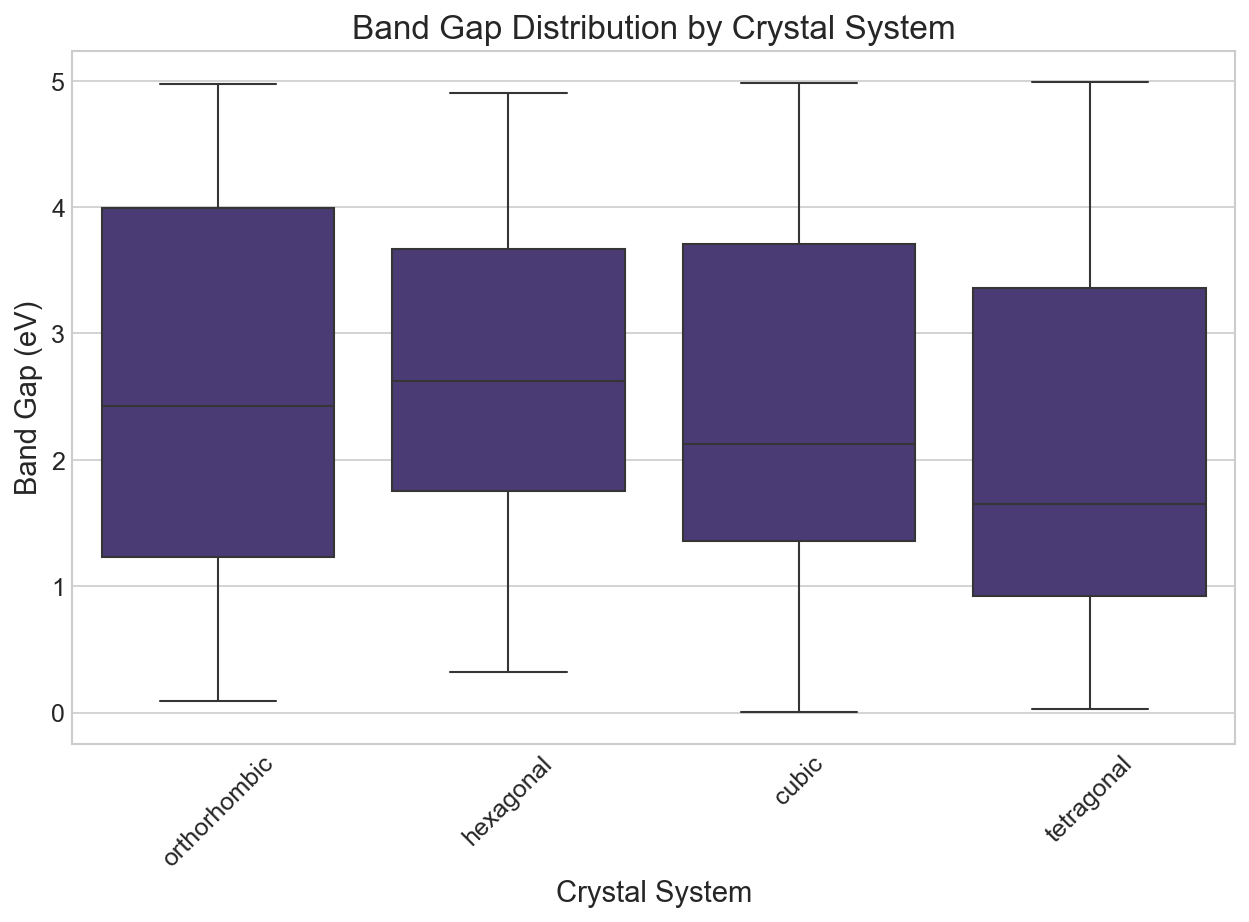

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='crystal_system', y='band_gap', data=df)
plt.xlabel('Crystal System')
plt.ylabel('Band Gap (eV)')
plt.title('Band Gap Distribution by Crystal System')
plt.xticks(rotation=45)
plt.show()

**Explanation**:
- `sns.boxplot()` takes column names for x (categorical) and y (numerical).
- Seaborn automatically computes the statistics and draws the box.
- The box shows the interquartile range (IQR), the line inside is the median, and the whiskers extend to points within 1.5×IQR; points beyond are shown as outliers.

### 5.2 Violin Plot
Violin plots combine box plots with kernel density estimation, showing the full distribution shape.

**When to use**: When you want to see both summary statistics and the probability density of the data.

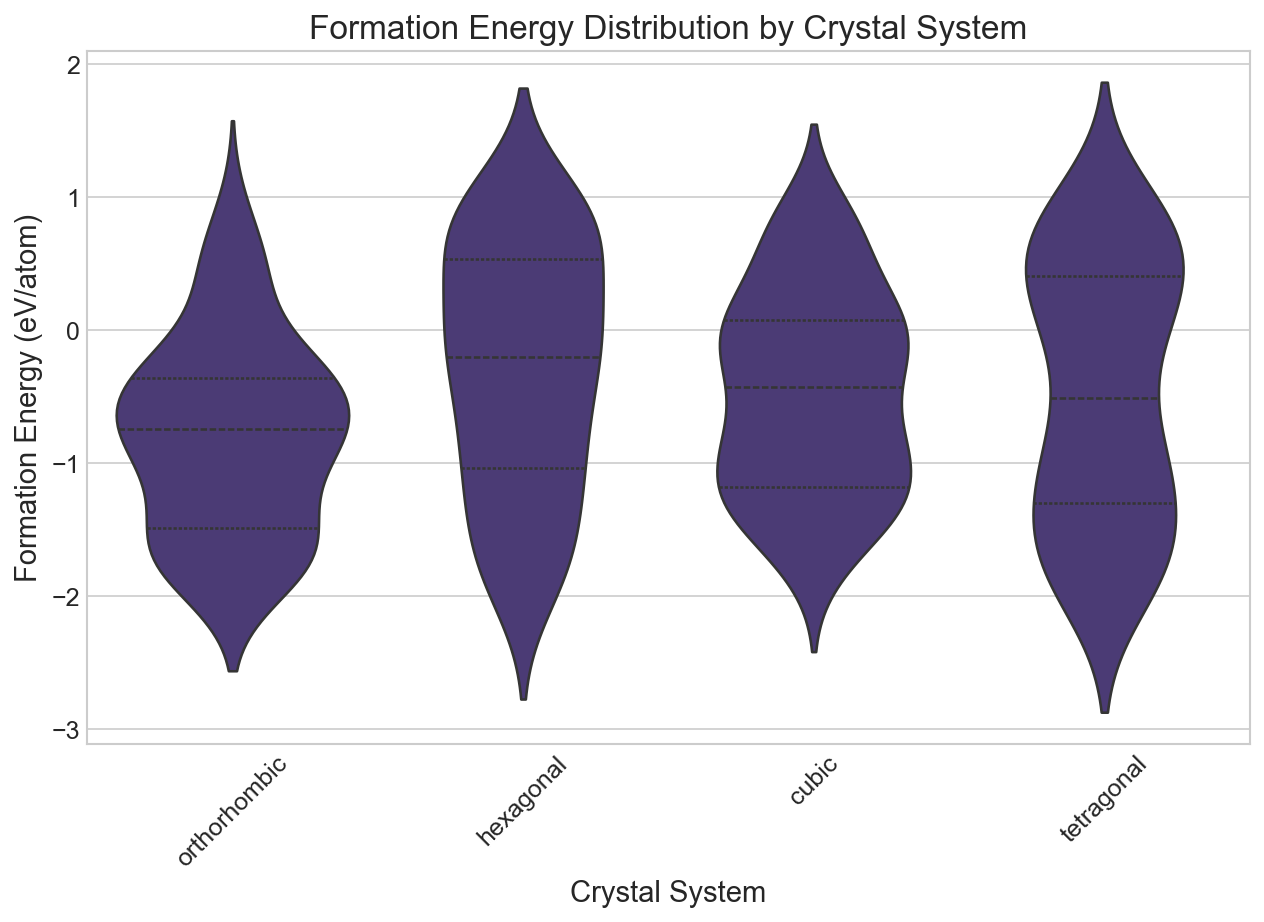

In [14]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='crystal_system', y='formation_energy_per_atom', data=df, inner='quartile')
plt.xlabel('Crystal System')
plt.ylabel('Formation Energy (eV/atom)')
plt.title('Formation Energy Distribution by Crystal System')
plt.xticks(rotation=45)
plt.show()

**Explanation**:
- `inner='quartile'` shows quartile lines inside the violin.
- The width of the violin at a given y‑value represents the density of data at that value.

### 5.3 Heatmap (Correlation Matrix)
Heatmaps are perfect for visualising correlations between numerical variables.

**When to use**: Exploring relationships between many variables at a glance.

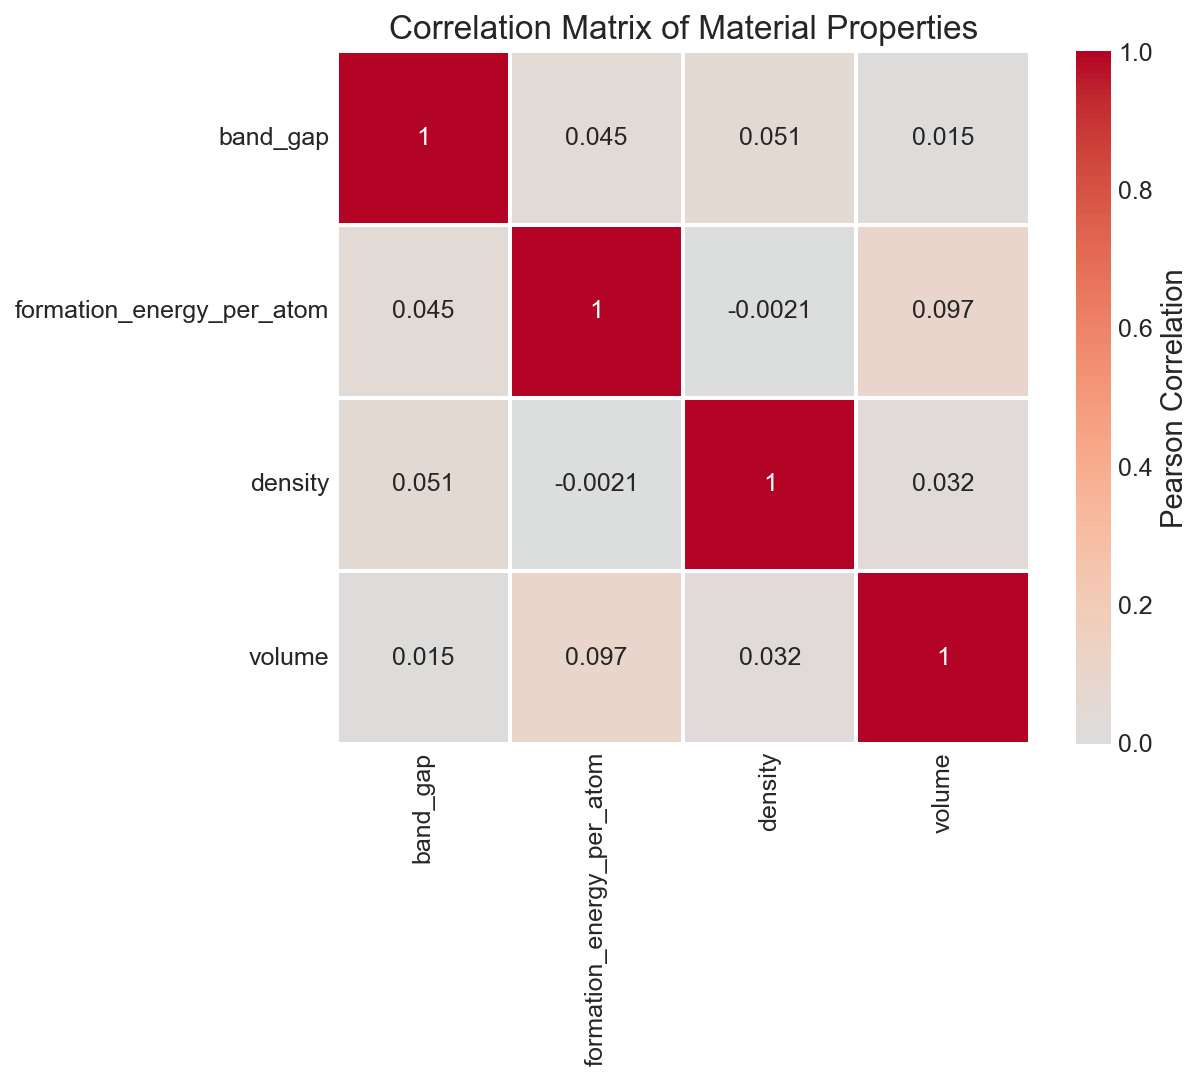

In [15]:
# Compute correlation matrix for numerical columns
numeric_cols = ['band_gap', 'formation_energy_per_atom', 'density', 'volume']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True,
            linewidths=1, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix of Material Properties')
plt.show()

**Explanation**:
- `df.corr()` computes the Pearson correlation coefficient between each pair of numerical columns.
- `annot=True` displays the correlation values inside the heatmap cells.
- `cmap='coolwarm'` is a diverging colour map suitable for correlations.
- `center=0` ensures that zero correlation is shown as white (or the midpoint of the colour map).
- `square=True` makes cells square.

### 5.4 Pair Plot
Pair plots give a quick overview of relationships between multiple variables, showing scatter plots for each pair and histograms (or KDE) on the diagonal.

**When to use**: Initial exploration of a dataset to spot trends, clusters, and outliers.

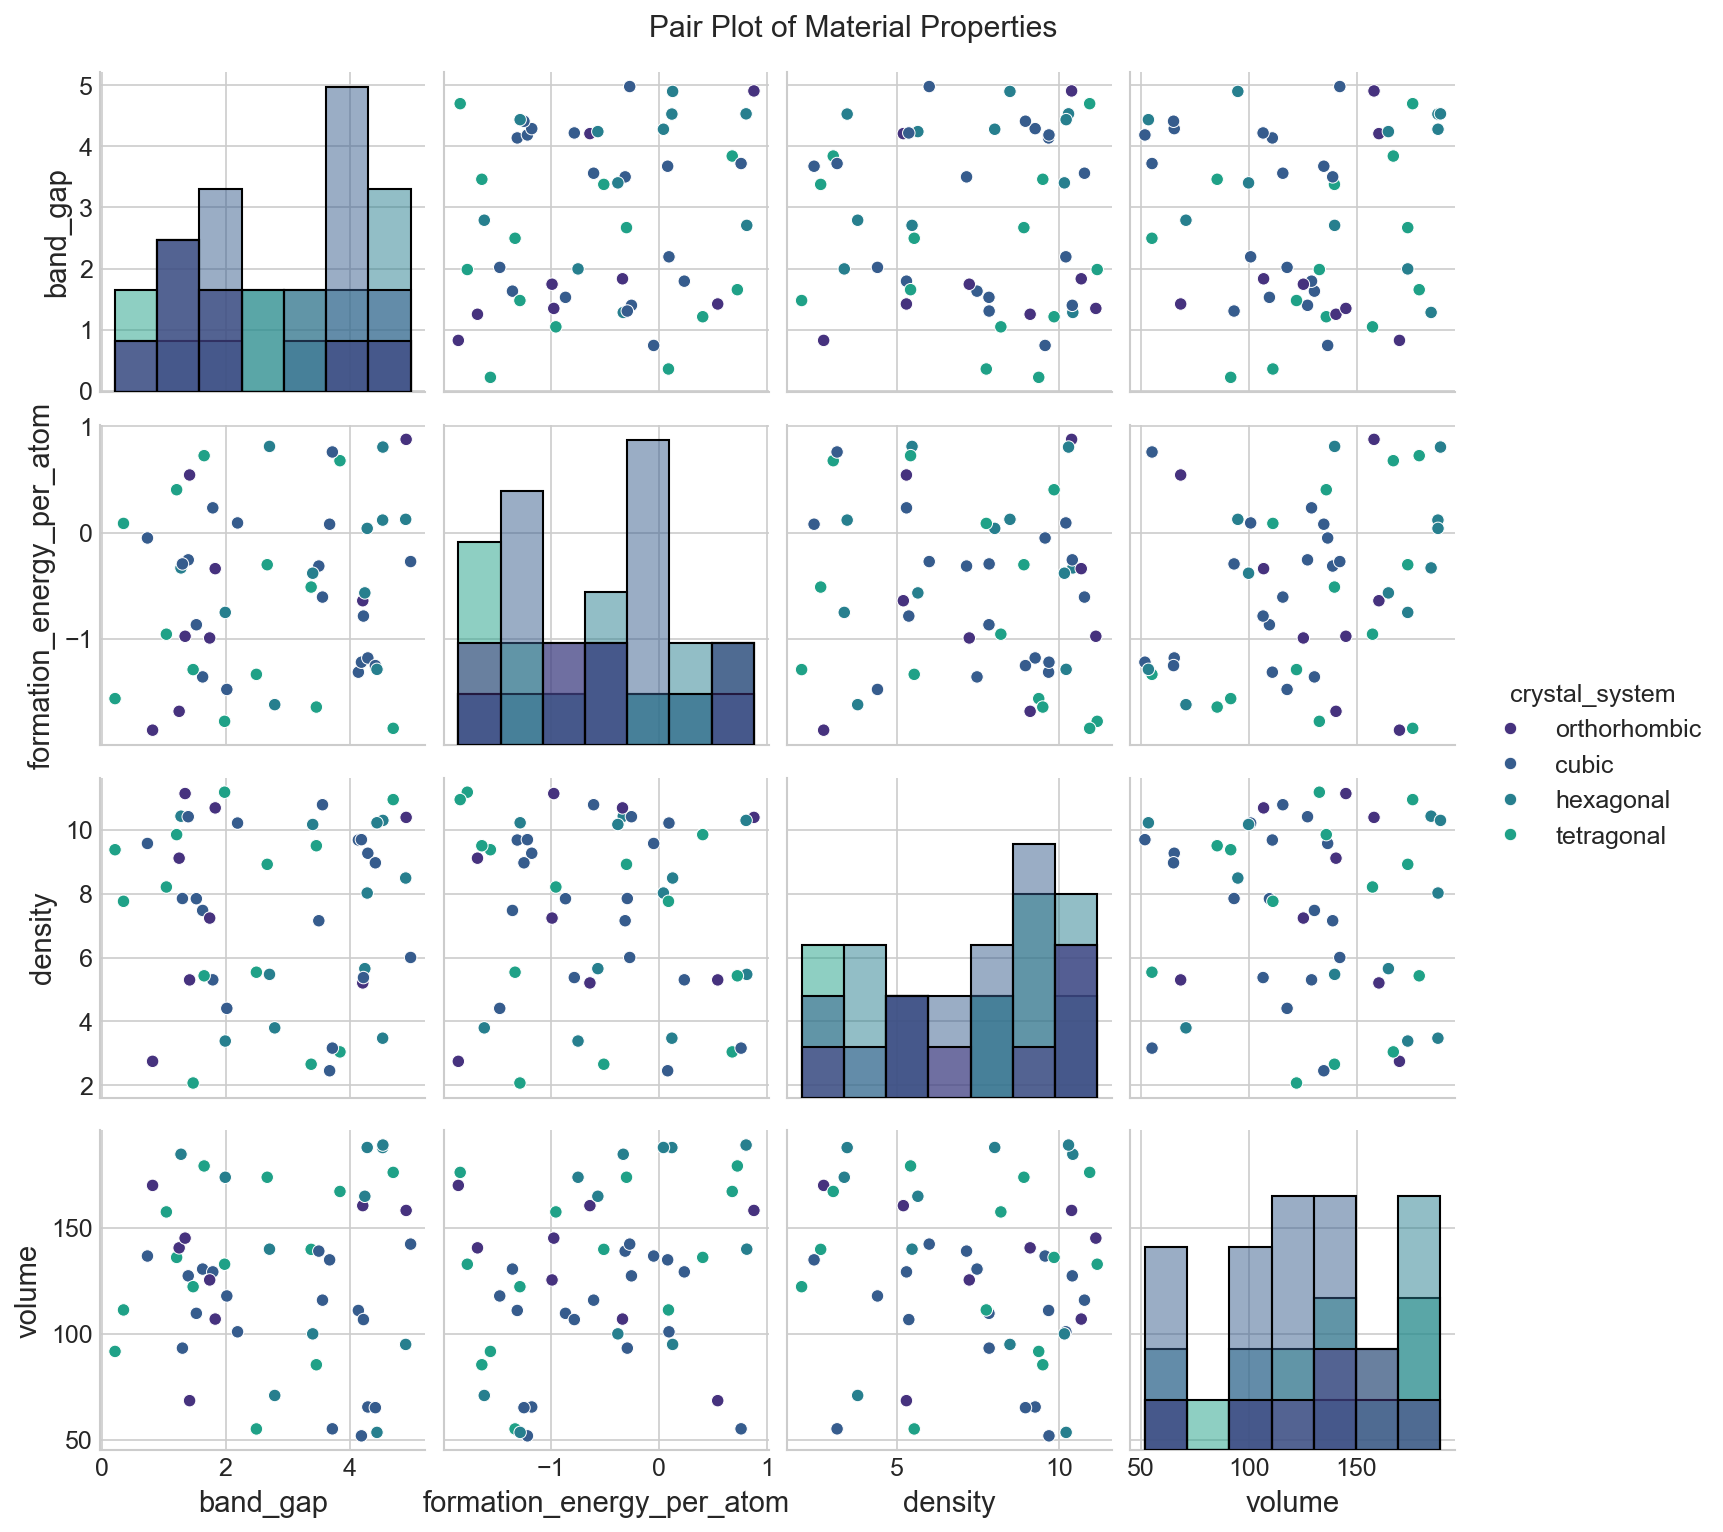

In [16]:
# Use a sample of the data to keep the plot readable (pair plots can be heavy with many points)
sample_df = df.sample(50, random_state=42)
sns.pairplot(sample_df, vars=numeric_cols, hue='crystal_system', diag_kind='hist')
plt.suptitle('Pair Plot of Material Properties', y=1.02)
plt.show()

**Explanation**:
- `hue='crystal_system'` colours points by crystal system and adds a legend.
- `diag_kind='hist'` shows histograms on the diagonal (alternatives: 'kde').
- We use a random sample of 50 points to avoid overcrowding.

**Exercise 5.1**: Create a box plot of density for each crystal system. Then create a violin plot of volume for each crystal system.

In [17]:
# Your code here

---
## 6. Saving Figures for Publication

Once you have created a figure you're happy with, you can save it to a file. Use `plt.savefig()` with appropriate parameters for high resolution. Saving as PDF is often preferred for publications because it is a vector format and scales without loss of quality.

**Important**: Call `plt.savefig()` before `plt.show()`, otherwise an empty file may be saved.

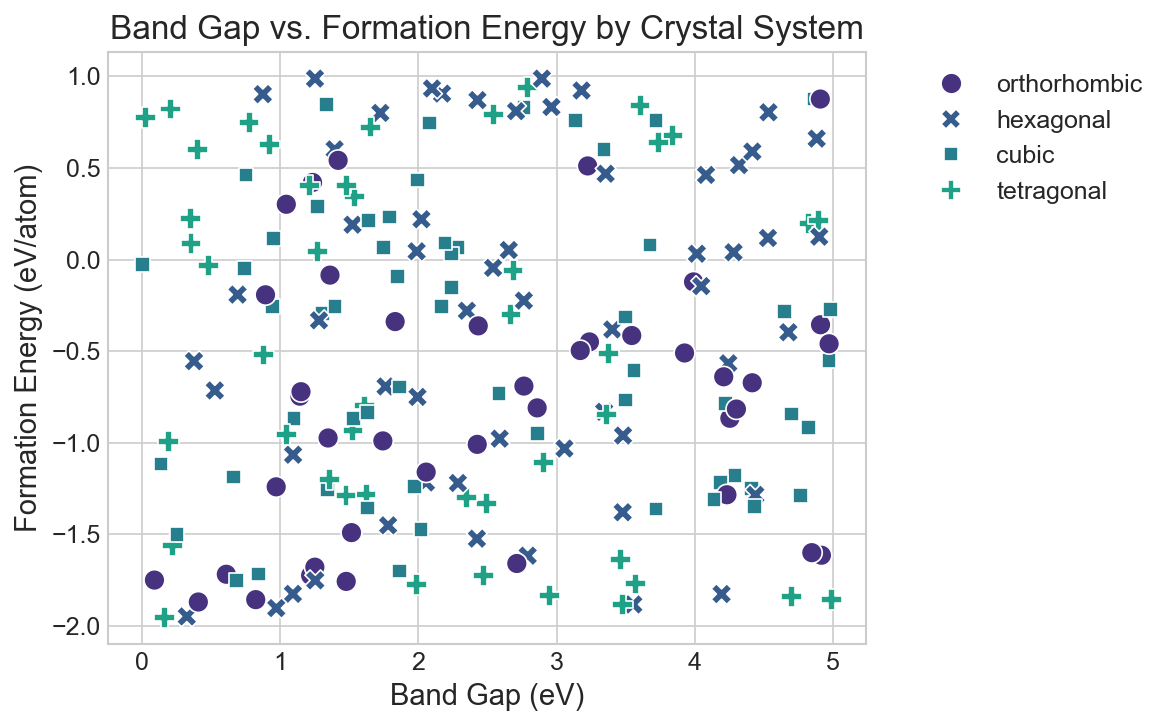

In [18]:
# Create a nice scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='band_gap', y='formation_energy_per_atom', hue='crystal_system',
                style='crystal_system', s=100, data=df)
plt.xlabel('Band Gap (eV)')
plt.ylabel('Formation Energy (eV/atom)')
plt.title('Band Gap vs. Formation Energy by Crystal System')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # place legend outside
plt.tight_layout()

# Save the figure (uncomment to actually save)
# plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')
# plt.savefig('scatter_plot.pdf', bbox_inches='tight')

plt.show()

**Explanation**:
- `dpi=300` sets the resolution to 300 dots per inch (standard for publication).
- `bbox_inches='tight'` ensures the saved figure includes all elements (e.g., legend) without extra white space.
- Saving as PDF produces a vector graphic that can be edited in tools like Adobe Illustrator.

**Exercise 6.1**: Create a heatmap of the correlation matrix and save it as a high‑resolution PNG file named `correlation_heatmap.png`.

In [19]:
# Your code here

---
## 7. Summary
In this lesson, we covered:
- Basic plots with Matplotlib (line, scatter, bar, histogram).
- Customising plots with colours, labels, legends, and colour bars.
- Creating subplots.
- Using Seaborn for statistical plots (box, violin, heatmap, pair plot).
- Saving figures for publication.

These visualisation skills will be invaluable as you explore and present your nanoinformatics data. In the next lessons, we will apply them to real data from the Materials Project and to the results of machine learning models.

---
## 8. Further Resources
- [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
- [Seaborn Documentation](https://seaborn.pydata.org/)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/index.html)
- [Seaborn Example Gallery](https://seaborn.pydata.org/examples/index.html)
- [Python Graph Gallery](https://python-graph-gallery.com/)

---
## 9. Self‑Assessment Questions
1. What function would you use to create a scatter plot in Matplotlib?
2. How do you add a legend to a plot?
3. What is the difference between a box plot and a violin plot?
4. How can you visualise the correlation between multiple numerical variables in a single plot?
5. Write the command to save a figure as a 300 DPI PNG file with tight bounding box.